<a href="https://colab.research.google.com/github/harshitha2115/Chat-Bot/blob/main/Xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

In [ ]:
data=pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data')

In [ ]:
x=data.drop(['name','status'],axis=1)
y= data['status']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42)
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:16:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
print('Accuracy:',accuracy_score(y_test,y_pred))
print("/nClassification Report:\n", classification_report(y_test,y_pred))

Accuracy: 0.9487179487179487
/nClassification Report:
               precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



In [ ]:
cm=confusion_matrix(y_test,y_pred)
print('/n Confusion matrix\n',cm)

/n Confusion matrix
 [[ 5  2]
 [ 0 32]]


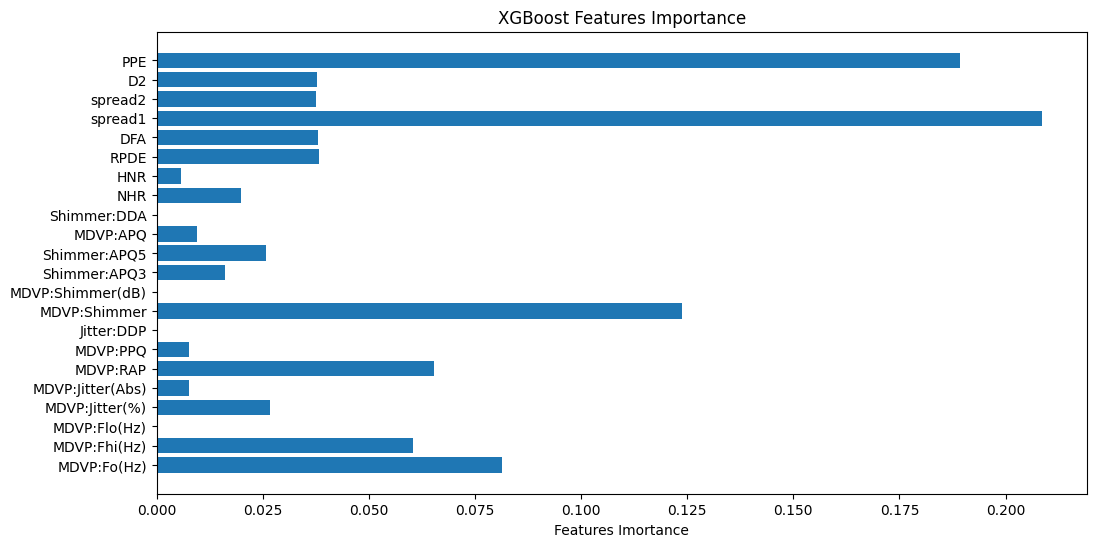

In [ ]:
plt.figure(figsize=(12,6))
plt.barh(x.columns,model.feature_importances_)
plt.xlabel('Features Imortance')
plt.title('XGBoost Features Importance')
plt.show()